# **Random Forest Classifier with Feature Importance**

---

## **Environment Setup (Local or Google Colab)**

The code block below automatically detects your execution runtime environment (Local vs. Google Colab), clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [ ]:
import os
import subprocess
import sys

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "main"
    repo_url = (
        "https://github.com/paymantohidifar/small-ml-projects.git"
    )
    target_dir = "/content/small-ml-projects"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e . --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")

In [ ]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## **Background**

Random Forest is an ensemble learning algorithm that constructs a collection of decorrelated decision trees to reduce variance without increasing bias. In this notebook, we build and evaluate Random Forest Classifiers for a binary classification task using the `lodetomasi1995/income-classification` dataset. We perform exploratory data analysis (EDA) to audit numerical and categorical distributions, establish preprocessing pipelines, and establish appropriate evaluation metrics.

Finally, we extract Mean Decrease in Impurity (Gini importance) to perform feature selection, retraining a pruned model on the top predictor subset to assess the trade-off between predictive performance and computational efficiency.

---

## **Access Raw Data**

To fetch data directly from Kaggle's repo, we will first obtain a Kaggle API key and store it in our Colab secrets, then use `kagglehub.dataset_download` function to download the dataset into Colab's `/content/income-classification` directory:

We use `kagglehub` module to download the dataset directly from Kaggle's repository:

In [2]:
import kagglehub

# Get KAGGLE API Token
from google.colab import userdata
userdata.get('KAGGLE_TOKEN');

# Download latest version using kagglehub API into Colab's local disk
kaggle_data_src = 'lodetomasi1995/income-classification'
path = kagglehub.dataset_download(
    handle=kaggle_data_src,
    output_dir='/content/income-classification')

print("Path to dataset files:", path)

# (Alternative method) Download using `kaggle` CLI
# !kaggle datasets download -d "lodetomasi1995/income-classification"

100%|██████████| 459k/459k [00:00<00:00, 73.2MB/s]

Extracting files...
Path to dataset files: /content/income-classification


We then use `Pandas` library to read CSV data into a dataframe ready for EDA:

In [3]:
from pathlib import Path
import pandas as pd

# Read dataset into Pandas DataFrame
data_filepath = Path(path) / "income_evaluation.csv"
df = pd.read_csv(data_filepath)

# Get the shape the dataset and preview first 5 lines
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---

## **Exploratory Data Analysis (EDA)**

### **Understand the Dataset**

To gain insight on our dataset, we start with EDA. First, let's find out about types of data in our dataframe and whether there are any missing values:

In [4]:
# Infomation on data types and missing values
df.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Our dataset is comprised of both numerical and categorical columns (features). Additionally, there seem to be no missing values.

Since nature of numerical and categorical columns/features are different, we will process them separately.

Let's preview all columns first:

In [5]:
df.columns.tolist()

['age',
 ' workclass',
 ' fnlwgt',
 ' education',
 ' education-num',
 ' marital-status',
 ' occupation',
 ' relationship',
 ' race',
 ' sex',
 ' capital-gain',
 ' capital-loss',
 ' hours-per-week',
 ' native-country',
 ' income']

We notice that except for `age`, rest of the columns are preceded with an extra space. To avoid hitting KeyError later, let's remove these extra space from columns names:

In [6]:
df.columns = df.columns.str.lstrip()
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

Then, we break columns into separate numerical and categorical features and invetigate them one by one:

In [7]:
# Numerical features
numerical = df.select_dtypes(include='number').columns.tolist()
print(f"Numerical features:\n {numerical}")

# Categorical features
categorical = df.select_dtypes(exclude='number').columns.tolist()
print(f"\nCategorical features:\n {categorical}")

Numerical features:
 ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


#### **Categorical Features**
We start with categorical features, first:

In [8]:
df[categorical].describe(include='all').T

,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital-status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native-country,32561,42,United-States,29170
income,32561,2,<=50K,24720


The summary table above illustrates various unique values for each feature.

Let's plot frequency of unique values for each feature:

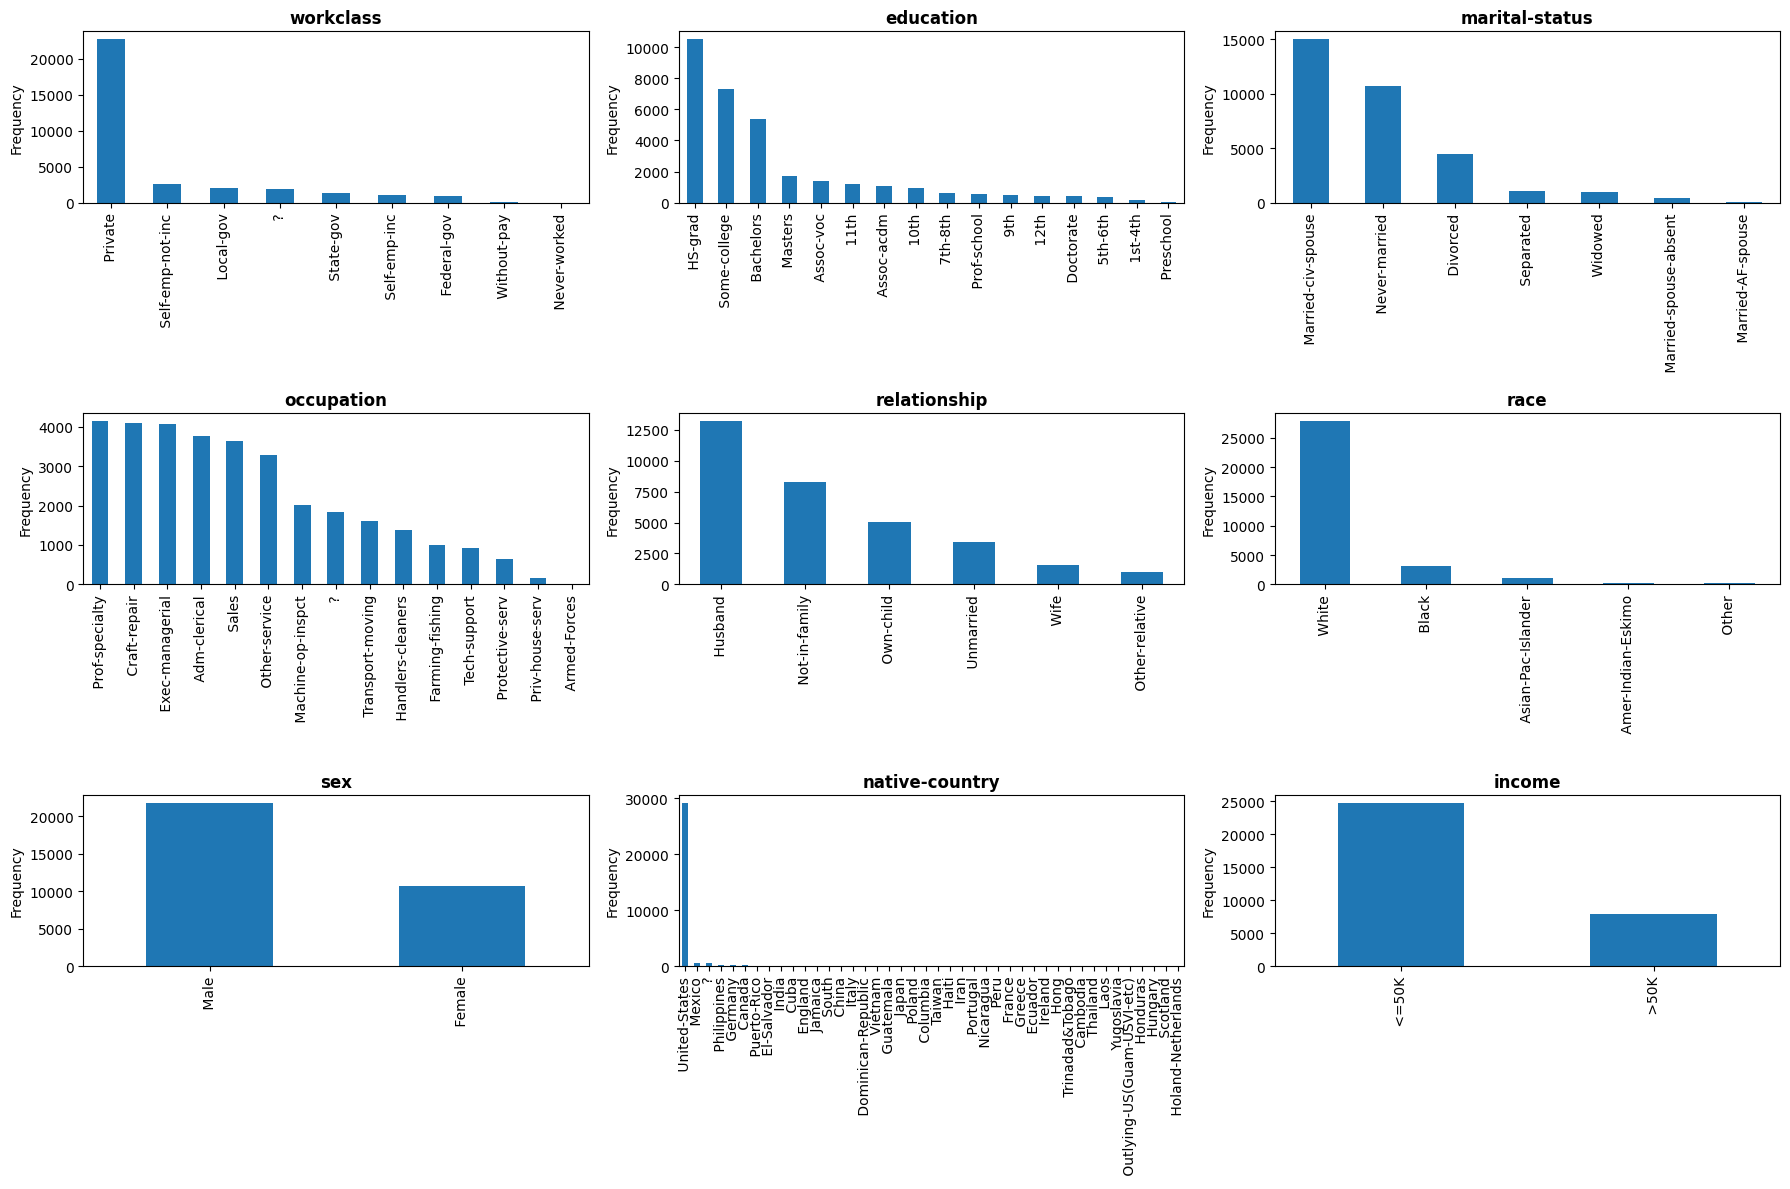

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), squeeze=True)
axes = axes.flatten()

for idx, feat in enumerate(categorical):
    ax = axes[idx]
    df[feat].value_counts().plot.bar(ax=ax)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel('Frequency')
    ax.grid(False)

plt.tight_layout()

Carefully going through the plots, we notice several features, namely `workclass`, `occupation`, and `native_country`, contain values denoted by `?`, suggesting missing information. Therefore, we will treat them as missing values and flag them with NaN (Not a Number) using `np.nan`. Later, we will need to drop them from the dataframe entirely or impute them to some meaningful values.

In [10]:
import numpy as np

df.replace(' ?', np.nan, inplace=True)

In [11]:
# Verify conversion
df['workclass'].value_counts(dropna=False)

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
NaN,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


#### **Encoding Categorical Features**

Models can only process floating point numbers. Therefore, we must encode categorical values to numbers. This is usually done using tools like `OneHotEncoder` or `category_encoder` depending on how we want to process our data: the fomer outputs Numpy Array while the latter preserves original Pandas DataFrame.

Note that we can always convert data types back and forth. What important here is that both tools encode feature values using **One-Hot Encoding** method. In this method, a feature with $K$ categories will be converted to $K-1$ or $K$ new sub-features, where values of new sub-featires would be either 1 or 0 (This is what "One-Hot" coding refers to).

One-hot encoding all $K$ categories introduces the "Dummy Variable Trap", potentially leading to perfect multicollinearity. While this breaks unregularized linear models like Ordinary Least Squares (OLS), tree-based models and regularized regressions are unaffected. Since we will use tree-based models in this notebook, we will set `drop='if_binary'` to eliminate redundant columns for binary features while preserving structural symmetry for multi-class variables.

Another important note is cardinality of a categorical feature. High-cardinal features (rule of thumb: $K \gt 50$) can lead to high feature-to-sample ratio and adversly affect model performance (e.g. overfitting). In this case, it's safer to go with other encoding methods, such as `Target Encoding`, `Ordinal Encoding`, and `Count Encoding` or use other models such as `LightGBM` or `CatBoost`. These models' can robustly handle categorical features with high cardinality.

Looking at our categorical features, highest cardinality belongs to `native_country` feature, where `cardinality=42`. Since $K \lt 50$, we will safely use "One-hot encoding" method.

We will integrate one-hot encoding to our training/inference pipeline later. But for the demonstration purpose, let's see how one-hot encoding works:

In [38]:
# Method 1: OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

# Transform categorical columns to binary features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary', dtype='int8')
ohe_arr = ohe.fit_transform(df[categorical])

# Convert Numpy Array to Pandas dataframe with feature names
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out()) # Make sure to specify dtype. Otherwise, dtype will be float.

# Preview top 5 rows
ohe_df.head()

,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,workclass_nan,education_ 10th,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,native-country_nan
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Instead of converting one-hot encoder's output to a Pandas dataframe manually, we could do this by setting `sklearn.set_config` right before our transformation pipeline:

```python
import sklearn
sklearn.set_config(transform_output="pandas")
```

One drawback with this approach is that this setting is applied globally and may break our subsequent implementations.

To use second tool, we need to make sure the library is available. If not we have to install it. The following bash script should take care of it for us:

In [23]:
%%bash
PACKAGE="category_encoders"
if pip show "$PACKAGE" > /dev/null 2>&1; then
    echo " Bypassing: '$PACKAGE' is already available in this Colab runtime."
else
    echo " Missing: Installing '$PACKAGE' now..."
    pip install -q "$PACKAGE"
fi

 Missing: Installing 'category_encoders' now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [39]:
# Method 2: category_encoder
import category_encoders as ce

# One-hot encode categorical features using `category_encoder`
ce_ohe = ce.OneHotEncoder(handle_unknown='ignore', use_cat_names=True)
ce_ohe_df = ce_ohe.fit_transform(df[categorical])

ce_ohe_df.head()

,workclass_ State-gov,workclass_ Self-emp-not-inc,workclass_ Private,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Self-emp-inc,workclass_ Without-pay,workclass_ Never-worked,workclass_nan,education_ Bachelors,...,native-country_ Scotland,native-country_ Trinadad&Tobago,native-country_ Greece,native-country_ Nicaragua,native-country_ Vietnam,native-country_ Hong,native-country_ Ireland,native-country_ Hungary,native-country_ Holand-Netherlands,native-country_nan
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


#### **Numerical Features**

In the following section, we will focus on numerical features.

To learn more about data, we will look at the summary statistics and use Seaborn's `pairplot` to visualize each feature's values against another feature's values:

In [25]:
df[numerical].describe(include='all').round(2).T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.37,105549.98,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0


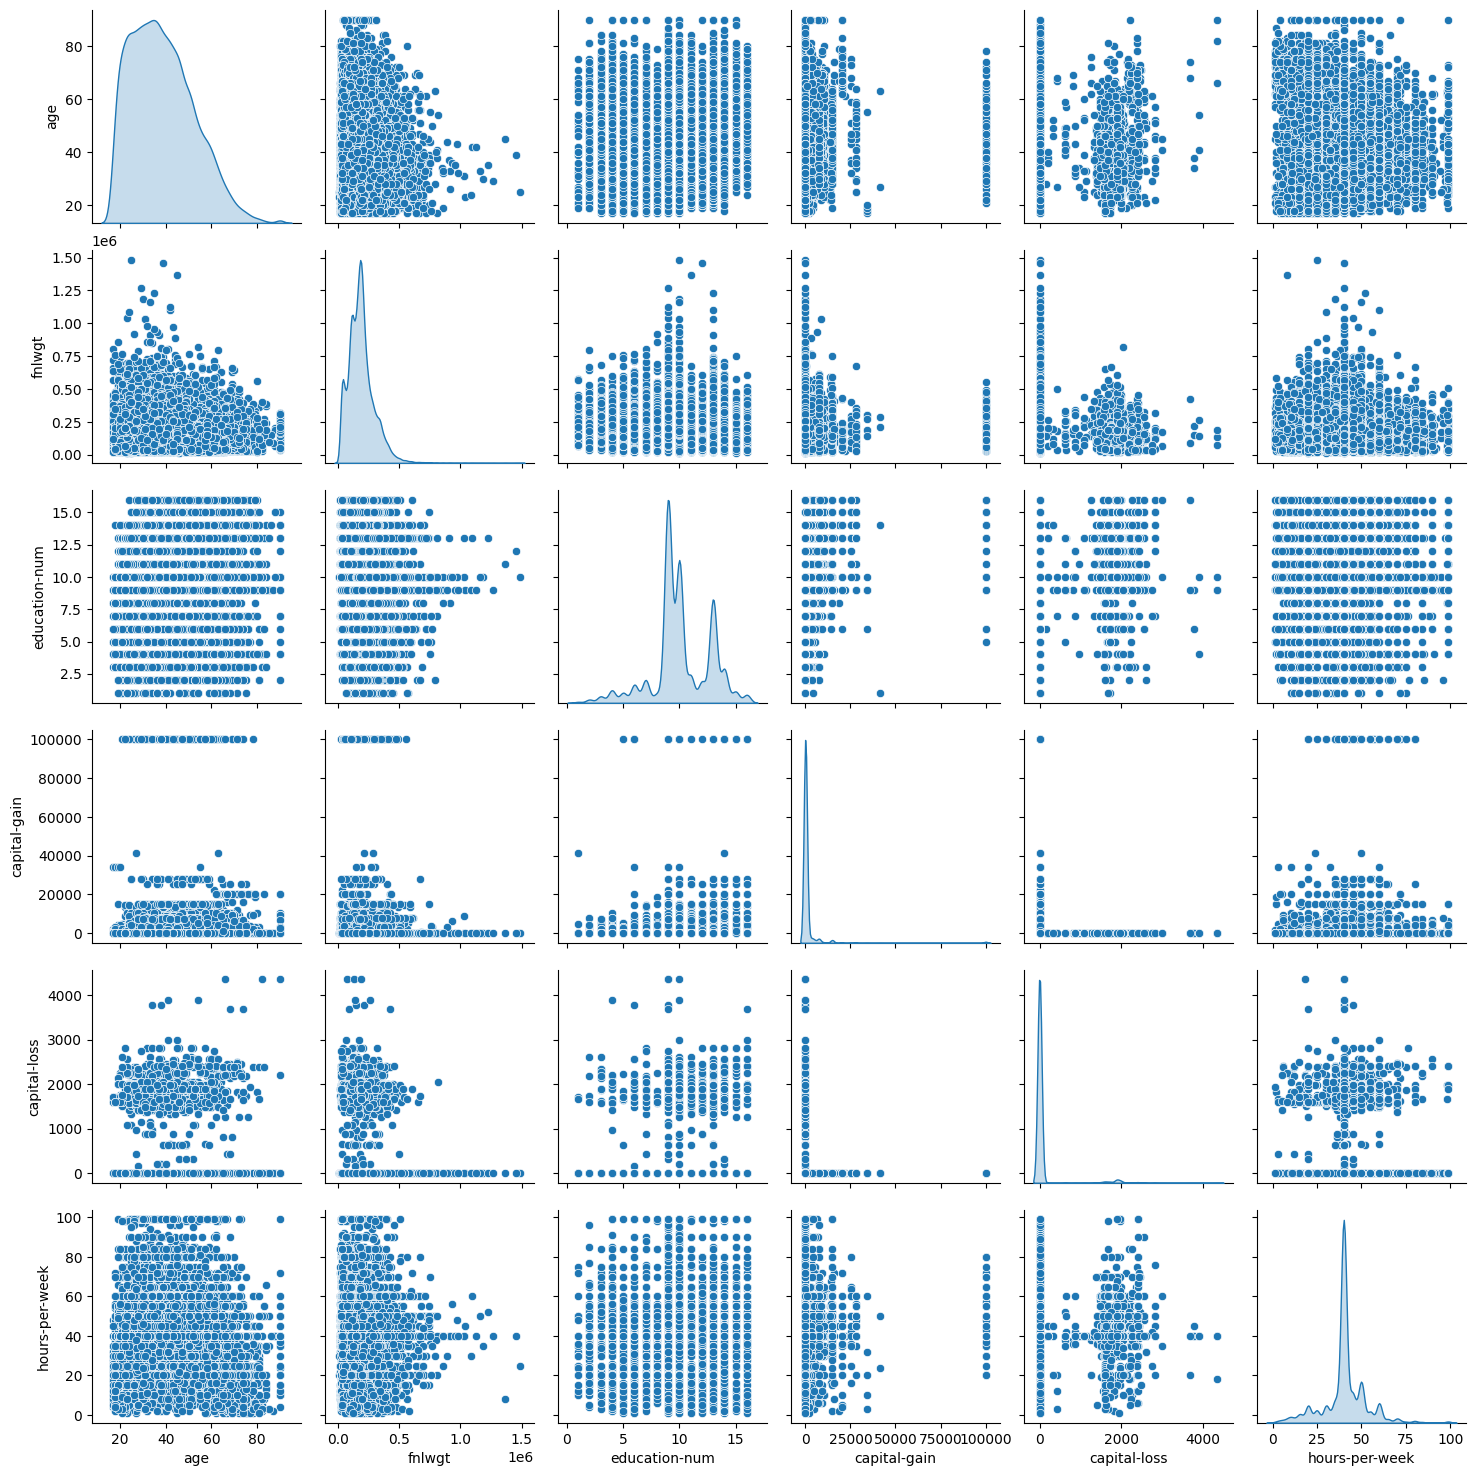

In [26]:
import seaborn as sns

_ = sns.pairplot(
    data = df[numerical],
    kind = 'scatter',
    diag_kind = 'kde'
)

Summary statistics and pair plots indicate three important realities about the numerical features:

1. Scale and range of feature values vary significantly.
2. Some of features deviate from normal distribution.
3. A few features carry outliers.
4. We don't see colinearity between features.

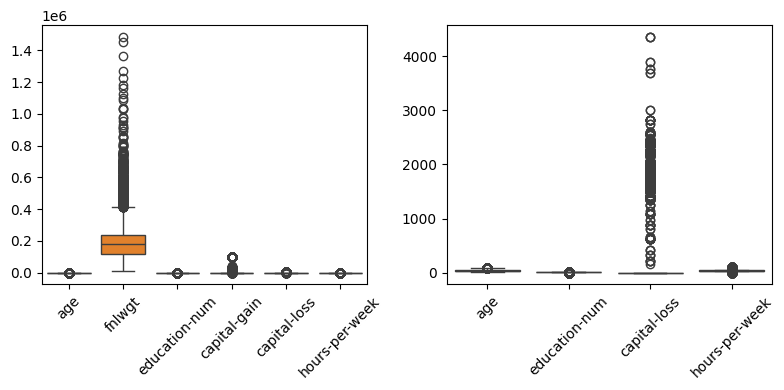

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), squeeze=True)

sns.boxplot(data=df[numerical], ax=ax1);
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45);

sns.boxplot(data=df[['age', 'education-num', 'capital-loss', 'hours-per-week']], showfliers=True, ax=ax2);
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45);

plt.tight_layout()

Based on the plots shown above, features such as `fnlwgt`, `capital gain`, `capital-loss`, and perhaps `hours-per-week` have high number of outliers. Also, it is evident from box plots that feature have different scales, as mentioned earlier.

It should be noted correlated features do not add information to the model and are considered redundant and can degrade the model's generalization. Therefore, we should exclude them from our dataset.

Let's numerically verify whether any two feature have moderate to strong correlation. Since the features do not follow a Gaussian distribution, a non-parametric method such as **Spearman** would be a more appropriate approach to compute correlation coefficients. However, for demostration purpose, we will compute corelation coefficients using both **Spearman** and **Pearson**:

In [28]:
# Spearman method
sp_corr_matrix = df[numerical].corr(method='spearman').round(2)
sp_upper_tri = sp_corr_matrix.where(np.triu(np.ones(sp_corr_matrix.shape), k=1).astype(bool))
print(sp_upper_tri)

print(100*'-')

# Pearson method
pr_corr_matrix = df[numerical].corr(method='pearson').round(2)
pr_upper_tri = pr_corr_matrix.where(np.triu(np.ones(pr_corr_matrix.shape), k=1).astype(bool))
print(pr_upper_tri)

                age  fnlwgt  education-num  capital-gain  capital-loss  \
age             NaN   -0.08           0.07          0.12          0.06   
fnlwgt          NaN     NaN          -0.04         -0.01         -0.01   
education-num   NaN     NaN            NaN          0.12          0.07   
capital-gain    NaN     NaN            NaN           NaN         -0.07   
capital-loss    NaN     NaN            NaN           NaN           NaN   
hours-per-week  NaN     NaN            NaN           NaN           NaN   

                hours-per-week  
age                       0.14  
fnlwgt                   -0.02  
education-num             0.17  
capital-gain              0.09  
capital-loss              0.06  
hours-per-week             NaN  
----------------------------------------------------------------------------------------------------
                age  fnlwgt  education-num  capital-gain  capital-loss  \
age             NaN   -0.08           0.04          0.08          0.06   
f

All correlation coefficients are below 0.2, indicating no colinearity between numerical features.

#### **Scaling Numerical Features**

In parametric models, such as Logistic Regression, it is critical that feature values share a similar scale. When features exist on radically different scales, it is highly recommended to normalize or standardize the data to put all features on an equal playing field.

This preprocessing step offers two major advantages:

1. **Accelerates Convergence:** It optimizes the loss landscape, allowing gradient-based optimization algorithms to converge significantly faster.
2. **Enables Model Interpretability:** Because the inputs are normalized, the resulting model weights carry standardized information. This makes it possible to correctly interpret the relative importance of features based on the magnitude of their coefficients.

Tree-based models (e.g., Random Forests and Gradient Boosted Trees), however, are inherently invariant to feature scaling. Because tree architectures split nodes based on the relative rank and order of the data rather than absolute geometric distances or magnitudes, unscaled features do not distort their decision boundaries.

To demonstrate this characteristic and show how it is conducted in a ML pipeline, we will train two separate Random Forest models, one utilizing scaled data and another utilizing unscaled data, and compare their performance metrics.

---

## **Training Models**

### **Preparing Train and Test Sets**

First step in the workflow is preparing data subsets. Typically, we split the dataset into mutually exclusive train, validation (dev), and test sets.

It should be noted that the subsets must be prepared before any preprocessing steps, such as imputation or scaling, happens to prevent data leakage from the training set into the validation or test set.

Additionally, we should check for class imbalance in our target (i.e. `income`). For imbalanced targets, stratified sampling based on the label values is highly recommended to guarantee both the training and valid/test sets mirror the same underlying class distribution.

In advanced pipelines, it is also recommended to flag missing values and stratify data across the joint distribution of both targets and missingness patterns to maintain structural data integrity.

In this notebook, we will only focus on target values.

Let's look at distribution of our target classes:

In [29]:
df['income'].value_counts(normalize=True, dropna=False)

,proportion
income,
<=50K,0.75919
>50K,0.24081


Around 75% of the target values belong to the `<=50K` class, while approximately 25% belong to the `>50K` class.

While this income distribution is not severely imbalanced, applying stratified sampling would be a safer bet.

Moving forward, let's break the dataset into separate features and target dataframes. Then, encode categorical target classes to numerical values:
* $\text{<=50K} \rightarrow 0$
* $\text{>50K} \rightarrow 1$

In [30]:
# Set features to X
X = df.drop('income', axis=1)

# Set target to y and encode classes into 0 and 1
y = df['income'].map({' <=50K': 0, ' >50K': 1}, na_action='ignore').astype('int8')

# Verify target encoded classes
print(y.value_counts(normalize=True))

income
0    0.75919
1    0.24081
Name: proportion, dtype: float64


For a dataset of this size (\~32K rows), a $0.6/0.2/0.2$ split is common. This allocation would reserve 60% of the data (\~19.5K rows) for training, large enough for the model to learn robust patterns, also leaving a substantial 20% validation pool (~6.5K rows) to finetune the model, and another 20% to assess model performance to generalize.

In our pipeline, we will use Scikit-learn's internal functions to automatically allocate validation sets for finetuning. Therefore, we will split the dataset into train and test sets at this stage:

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print("Train set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)

Train set shape:  (26048, 14)
Test set shape:  (6513, 14)


### **Preprocessing Train and Test Sets**

In the following section, we will generate two distinct variations of our dataset to evaluate the impact of feature scaling and missing value handling on model's performance:

1. **`X_train_pre_1` & `X_test_pre_1` (Categorical Encoding and Imputation):** This pipeline applies one-hot encoding and missing value imputation exclusively to categorical features but leaves numerical features completely unscaled to establish a baseline for our tree-based models.

2. **`X_train_pre_2` & `X_test_pre_2` (Fully Preprocessed):** This pipeline applies one-hot encoding and missing value imputation to categorical features, alongside standardization (scaling) for numerical features.

Note that our numerical features carry a significant number of outliers. Therefore, rank-based standardization, such as `RobustScaler` is preferred. Briefly, `RobustScaler` removes the median and scales the data according to the quantile range (IQR) rather than mean and standard deviation:

$$x_{scaled} = \frac{x - Median(x)}{IQR}$$

Let's generate first version of train/test datasets:

In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# Update categorical features since 'income' is removed
categorical = X_train.select_dtypes(exclude='number').columns.tolist()

# Set up transformer pipeline for categorical features
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='int8'))
])

# Instantiate column transformer for categorical features
preprocessor_1 = ColumnTransformer(
    transformers=[('cat', cat_transformer, categorical)],
    remainder='passthrough',
    verbose_feature_names_out=False # This line avoids prefix added to column labels
).set_output(transform="pandas")

# Transform X_train and X_test datasets
X_train_pr1 = preprocessor_1.fit_transform(X_train)
X_test_pr1 = preprocessor_1.transform(X_test)

print("X_train shape after preprocessing 1: ", X_train_pr1.shape)
print("X_test shape after preprocessing 1: ", X_test_pr1.shape)

X_train shape after preprocessing 1:  (26048, 105)
X_test shape after preprocessing 1:  (6513, 105)


In [33]:
X_train_pr1.head()

,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 10th,education_ 11th,...,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
15738,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,32,37210,13,0,0,45
27985,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,43,101950,14,0,0,45
30673,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,20,122244,9,0,0,28
9505,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,40,24763,10,6849,0,40
26417,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,24,113936,13,0,0,40


In [36]:
X_train_pr1.columns.tolist()

['workclass_ Federal-gov',
 'workclass_ Local-gov',
 'workclass_ Never-worked',
 'workclass_ Private',
 'workclass_ Self-emp-inc',
 'workclass_ Self-emp-not-inc',
 'workclass_ State-gov',
 'workclass_ Without-pay',
 'education_ 10th',
 'education_ 11th',
 'education_ 12th',
 'education_ 1st-4th',
 'education_ 5th-6th',
 'education_ 7th-8th',
 'education_ 9th',
 'education_ Assoc-acdm',
 'education_ Assoc-voc',
 'education_ Bachelors',
 'education_ Doctorate',
 'education_ HS-grad',
 'education_ Masters',
 'education_ Preschool',
 'education_ Prof-school',
 'education_ Some-college',
 'marital-status_ Divorced',
 'marital-status_ Married-AF-spouse',
 'marital-status_ Married-civ-spouse',
 'marital-status_ Married-spouse-absent',
 'marital-status_ Never-married',
 'marital-status_ Separated',
 'marital-status_ Widowed',
 'occupation_ Adm-clerical',
 'occupation_ Armed-Forces',
 'occupation_ Craft-repair',
 'occupation_ Exec-managerial',
 'occupation_ Farming-fishing',
 'occupation_ Handl

After data transformation, we ended up with 105 features. Now, let's generate  the second version of train/test datasets with additional scaling transformation on numerical features:

In [ ]:
from sklearn.preprocessing import RobustScaler

# Set up transformer pipeline for categorical features
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='int8'))
])

# Instantiate column transformer for categorical and numerical features accordingly
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, categorical),
        ('num', RobustScaler(), numerical)
        ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

# Transform X_train and X_test datasets
X_train_pr2 = preprocessor_2.fit_transform(X_train)
X_test_pr2 = preprocessor_2.transform(X_test)

print("X_train shape after preprocessing 2: ", X_train_pr2.shape)
print("X_test shape after preprocessing 2: ", X_test_pr2.shape)

In [ ]:
X_train_pr2.head()

Let's see how scaling transformed the numerical features:

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), squeeze=True)

sns.boxplot(data=X_train_pr2[numerical], ax=ax1);
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45);

sns.boxplot(data=X_train_pr2[numerical], showfliers=False, ax=ax2);
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45);

plt.tight_layout()

The figure above demonstrates that the numerical features have been successfully brought to a similar scale. Notably, while the extreme outliers within the `Capital-gain` feature are preserved, they did not skew or distort the center (median) or dispersion (IQR) of the dataset. This highlights the architectural advantage of using a robust scaling approach.

---

## **Training Random Forest Classifiers**

In this section, we will train two classifiers per dataset using two different values for the `n_estimators` hyperparameter—a parameter that is typically fine-tuned when optimizing tree-based ensembles. Our objective is to observe how increasing the number of estimators (individual decision trees) impacts the model's overall predictive performance and stability.

### **Train/Test Dataset 1**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#----- Hyperparameter 1: `n_estimators=10` -----#
rf1_10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf1_10.fit(X_train_pr1, y_train)

#----- Hyperparameter 2: `n_estimators=100` -----#
rf1_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf1_100.fit(X_train_pr1, y_train)

### **Train/Test Dataset 2**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#----- Hyperparameter 1: `n_estimators=10` -----#
rf2_10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf2_10.fit(X_train_pr2, y_train)

#----- Hyperparameter 2: `n_estimators=100` -----#
rf2_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2_100.fit(X_train_pr2, y_train)

---

## **Model Performance Evaluation and Metric Selection**

By default, scikit-learn uses classification **accuracy**, which treats all errors equally. In real-world applications, a False Positive (false alarm) rarely carries the same cost as a False Negative (missed detection). Selecting a metric aligned with your data distribution and decision-making criteria is critical for effective model evaluation.


### **Single-Value Metrics**

The following matrix outlines the strategic criteria for selecting a hard-label evaluation metric:

| Metric | Selection Criteria | Mathematical Focus | Real-World Examples |
| --- | --- | --- | --- |
| **Accuracy** | Balanced classes; equal error costs. | $\frac{\text{True Positives} + \text{True Negatives}}{\text{Total Samples}}$ | Symmetrical OCR, coin flips. |
| **Recall** *(Sensitivity)* | **Minimize False Negatives ($\text{FN}$).** Missing a positive case is critical. | $\frac{\text{True Positives}}{\text{True Positives} + \mathbf{False\ Negatives}}$ | Cancer screening, defect detection, cyber-intrusion tracking. |
| **Precision** | **Minimize False Positives ($\text{FP}$).** False alarms cause damage or fatigue. | $\frac{\text{True Positives}}{\text{True Positives} + \mathbf{False\ Positives}}$ | Spam filtering, automated content moderation. |
| **F1-Score** | Imbalanced classes; requires an even trade-off. | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Customer churn, e-commerce recommendation engines. |

#### **1. Prioritizing Recall (Optimizing for False Negatives)**

In rare disease screening, a model can achieve 99% accuracy by predicting that every patient is healthy, completely missing the 1% who are sick. When missing a case carries severe consequences, optimize for **Recall** to minimize False Negatives.

* **Trade-off:** The model becomes highly sensitive, increasing False Positives (false alarms) to ensure no true positive is missed.

#### **2. Prioritizing Precision (Optimizing for False Positives)**

In automated content moderation, a False Positive mistakenly deletes an innocent user's comment, causing immediate frustration. When false alarms cause operational harm, optimize for **Precision** to minimize False Positives.

* **Trade-off:** The model becomes highly conservative, only predicting a positive label when absolutely certain, which increases False Negatives by letting borderline cases slip through.

#### **3. Balancing with F1-Score (The Harmonic Mean)**

Optimizing for Precision or Recall in isolation allows a model to "cheat." For example, a model can score 100% Recall by blindly predicting the positive class for every single row. The **F1-Score** prevents this by calculating the harmonic mean of both metrics. Because it uses a harmonic mean rather than a standard arithmetic average, the score penalizes extreme imbalances; if either precision or recall approaches zero, the overall F1-Score collapses.


### **Threshold-Agnostic Metrics**

Metrics like Accuracy, Precision, and Recall rely on hard classifications generated by applying a default operational threshold (typically $>0.5$) to raw predicted probabilities. If your system requires sorting risk, ranking instances, or evaluating raw probabilities, use threshold-agnostic metrics.

#### **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**

* **When to use:** When you need to assess overall class separability and probability ranking across all possible thresholds.
* **Interpretation:** It represents the probability that a randomly selected positive sample will receive a higher probability score than a randomly selected negative sample.

#### **PR-AUC (Precision-Recall Area Under Curve / Average Precision)**

* **When to use:** When evaluating datasets with extreme minority class imbalances (e.g., 99.9% negative vs. 0.1% fraudulent transactions).
* **Interpretation:** ROC-AUC can provide an overly optimistic view on imbalanced data because its formula includes True Negatives ($\text{TN}$), which completely overwhelms the calculation. PR-AUC strips True Negatives out entirely, forcing the evaluation matrix to focus exclusively on the true performance of the rare target class.

### **Balanced vs. Imbalanced Data**

In machine learning, there is no universal boundary that separates a balanced dataset from an imbalanced one, but an industry rule of thumb based on the minority class distribution can guide your engineering choices.

#### **Minority Class Distribution**

| Minority Class Proportion | Imbalance Level | Operational Impact |
| --- | --- | --- |
| **$> 40\%$** | Perfectly Balanced | Standard behavior. Use default metrics (Accuracy) and standard loss functions. |
| **$20\% - 40\%$** | Mild Imbalance | Generally safe. Most tree-based models (e.g., Random Forests, XGBoost) handle this natively without modification. |
| **$1\% - 20\%$** | Moderate Imbalance | **Action required.** Accuracy becomes a misleading metric. Switch evaluation metrics and apply `class_weight` adjustments. |
| **$< 1\%$** | Extreme Imbalance | **Specialized engineering required.** Standard algorithms will ignore the minority class. Requires sampling techniques or anomaly-detection architectures. |

#### **The Absolute Volume Check**

Class proportions are not the only factor; total data volume plays an equally critical role. Before deciding on an imbalance strategy, always evaluate the absolute number of minority samples:

* **Scenario A (Low Volume):** You have $1,000$ total examples, and the minority class is $1\%$ ($10$ examples). This is a critical statistical failure point; a model cannot learn generalized patterns from only $10$ rows. You must resample or collect more data.
* **Scenario B (High Volume):** You have $10,000,000$ total examples, and the minority class is $1\%$ ($100,000$ examples). Although the ratio indicates an "Extreme Imbalance," $100,000$ samples provide more than enough statistical power for a model to learn stable, complex features without artificial resampling.

### **Performance Analysis of Our Models**

With this foundational background in mind, let's revisit our dataset to determine the best evaluation strategy. In this specific study, neither False Positives nor False Negatives carry catastrophic real-world consequences. But our target labels fall into the "mildly-moderately imbalanced" category, with the minority class making up approximately 25% of the data:

$$\frac{\text{Count}(\text{income} > 50\text{K})}{\text{Total Samples}} = 0.25$$

Therefore, choosing **Accuracy** as our primary evaluation metric would not be quite reliable, but we will generate accuracy scores for demonstration purpose.

A safer bet would be **F1-Score**, which respects both classes. We will explore alternative classe-level metrics to evaluate model performances.

#### **Accuracy (for demonstration)**

In [ ]:
# ---- Train/Test dataset 1 ----#
# Hyperparameter 1: `n_estimators=10`
rf_1_10_train_score = rf1_10.score(X_train_pr1, y_train)
rf_1_10_test_score = rf1_10.score(X_test_pr1, y_test)

print('tr1_10 train score:', np.round(rf_1_10_train_score, 4))
print('tr1_10 test score:', np.round(rf_1_10_test_score, 4))
print()

# Hyperparameter 2: `n_estimators=100`
rf_1_100_train_score = rf1_100.score(X_train_pr1, y_train)
rf_1_100_test_score = rf1_100.score(X_test_pr1, y_test)

print('tr1_100 train score:', np.round(rf_1_100_train_score, 4))
print('tr1_100 test score:', np.round(rf_1_100_test_score, 4))
print()

In [ ]:
# ---- Train/Test dataset 2 ----#
# Hyperparameter 1: `n_estimators=10`
rf_2_10_train_score = rf2_10.score(X_train_pr2, y_train)
rf_2_10_test_score = rf2_10.score(X_test_pr2, y_test)

print('tr2_10 train score:', np.round(rf_2_10_train_score, 4))
print('tr2_10 test score:', np.round(rf_2_10_test_score, 4))
print()

# Hyperparameter 2: `n_estimators=100`
rf_2_100_train_score = rf2_100.score(X_train_pr2, y_train)
rf_2_100_test_score = rf2_100.score(X_test_pr2, y_test)

print('tr2_100 train score:', np.round(rf_2_100_train_score, 4))
print('tr2_100 test score:', np.round(rf_2_100_test_score, 4))
print()

All four models achieved near-perfect accuracy scores ($\gt 0.98$) on the training set. However, performance on the test sets dropped to approximately $0.85$. This notable gap between training and testing performance indicates a high-variance model that is overfitting to the training data. In the following sections, we will address this variance through hyperparameter fine-tuning.

Comparing the results between Dataset 1 and Dataset 2 confirms that scaling the numerical features did not improve model performance. This outcome aligns with the architectural design of Random Forests, which split nodes based on feature value ranking rather than absolute magnitude.

Finally, increasing the number of tree estimators from 10 to 100 yielded a slight improvement in model performance across both datasets, demonstrating that a larger ensemble helps stabilize predictions and reduce variance.

#### **F1-Score**

By default, scikit-learn calculates the F1-Score focusing exclusively on class `1` (the positive class). Because our operational objectives require us to treat both classes with equal importance, we should evaluate the unweighted average of the individual class scores instead.

In [ ]:
from sklearn.metrics import f1_score

# ---- Train/Test dataset 1 ----#
# Hyperparameter 1: `n_estimators=10`
y_pred_train_1_10 = rf1_10.predict(X_train_pr1)
rf_1_10_train_f1_score = f1_score(y_train, y_pred_train_1_10, average='macro')

y_pred_test_1_10 = rf1_10.predict(X_test_pr1)
rf_1_10_test_f1_score = f1_score(y_test, y_pred_test_1_10, average='macro')

print('tr1_10 train f1-score:', np.round(rf_1_10_train_f1_score, 4))
print('tr1_10 test f1-score:', np.round(rf_1_10_test_f1_score, 4))
print()

# Hyperparameter 2: `n_estimators=100`
y_pred_train_1_100 = rf1_100.predict(X_train_pr1)
rf_1_100_train_f1_score = f1_score(y_train, y_pred_train_1_100, average='macro')

y_pred_test_1_100 = rf1_100.predict(X_test_pr1)
rf_1_100_test_f1_score = f1_score(y_test, y_pred_test_1_100, average='macro')

print('tr1_10 train f1-score:', np.round(rf_1_100_train_f1_score, 4))
print('tr1_10 test f1-score:', np.round(rf_1_100_test_f1_score, 4))
print()

In [ ]:
# ---- Train/Test dataset 2 ----#
# Hyperparameter 1: `n_estimators=10`
y_pred_train_2_10 = rf2_10.predict(X_train_pr2)
rf_2_10_train_f1_score = f1_score(y_train, y_pred_train_2_10, average='macro')

y_pred_test_2_10 = rf2_10.predict(X_test_pr2)
rf_2_10_test_f1_score = f1_score(y_test, y_pred_test_2_10, average='macro')

print('tr2_10 train f1-score:', np.round(rf_2_10_train_f1_score, 4))
print('tr2_10 test f1-score:', np.round(rf_2_10_test_f1_score, 4))
print()

# Hyperparameter 2: `n_estimators=100`
y_pred_train_2_100 = rf2_100.predict(X_train_pr2)
rf_2_100_train_f1_score = f1_score(y_train, y_pred_train_2_100, average='macro')

y_pred_test_2_100 = rf2_100.predict(X_test_pr2)
rf_2_100_test_f1_score = f1_score(y_test, y_pred_test_2_100, average='macro')

print('tr2_10 train f1-score:', np.round(rf_2_100_train_f1_score, 4))
print('tr2_100 test f1-score:', np.round(rf_2_100_test_f1_score, 4))
print()

### **Fine-tunig Model To Reduce Variance**

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    scoring='f1_macro',
    cv=5,
    refit=True,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train_pr1, y_train)
print(rf_search.best_params_)

#### **Evaluating Class-Specific Metrics**

Now that we have evaluated our baseline models using the Accuracy metric, let’s expand our analysis. To get a granular view of how the model performs across each individual class, we will generate detailed evaluation matrices using scikit-learn's `classification_report` function. This will allow us to unpack **Precision**, **Recall**, and **F1-scores** simultaneously, ensuring that our model isn't hiding poor performance on the minority class behind a high baseline accuracy score.

In [ ]:
from sklearn.metrics import classification_report

# ---- Train/Test dataset 1 ----#
# Hyperparameter 1: `n_estimators=10`
y_pred1_10 = rf1_10.predict(X_test_pr1)

print(f"Classification report for dataset 1, hyperparameter 1: n_estimators=10")
print(classification_report(y_test, y_pred1_10))
print()

# Hyperparameter 2: `n_estimators=100`
y_pred1_100 = rf1_100.predict(X_test_pr1)

print(f"Classification report for dataset 1, hyperparameter 2: n_estimators=100")
print(classification_report(y_test, y_pred1_100))
print()

In [ ]:
# ---- Train/Test dataset 2 ----#
# Hyperparameter 1: `n_estimators=10`
y_pred2_10 = rf2_10.predict(X_test_pr2)

print(f"Classification report for dataset 2, hyperparameter 1: n_estimators=10")
print(classification_report(y_test, y_pred2_10))
print()

# Hyperparameter 2: `n_estimators=100`
y_pred2_100 = rf2_100.predict(X_test_pr2)

print(f"Classification report for dataset 2, hyperparameter 2: n_estimators=100")
print(classification_report(y_test, y_pred2_100))
print()

Evaluating the models via **Precision**, **Recall**, and **F1-Score** confirms that increasing the ensemble size to 100 trees systematically improves performance across nearly all core metrics. This expansion provides a more stable voting mechanism across individual estimators, directly enhancing the model's ability to minimize both False Positives and False Negatives.

However, even when analyzing these granular, class-specific metrics, feature scaling continues to have zero impact on the scores. This further reinforces the fact that tree-based models are entirely invariant to monotonic feature transformations.


#### **Analyzing the Class Performance Disparity**
A closer review of the scores reveals that the model performs significantly better on the majority class (`0`) than on the minority class (`1`). This performance disparity is a direct consequence of the class imbalance and higher absolute volume ($75\%$ vs. $25\%$) within the dataset.

Because the algorithm encounters roughly three times as many examples of class `0` as class `1`, its splitting criteria (e.g., Gini impurity or entropy) optimize heavily for the majority class. This effect is most pronounced in the **Recall** metric, which sits at `0.93` for class `0` compared to just `0.63` for class `1`.

Because the model is exposed to an abundance of negative samples, it develops highly accurate rules for them, successfully catching 93% of all actual negative cases. On the other hand, lacking sufficient minority data volume, the model becomes conservative when predicting the positive class. It completely misses 37% of true positive cases, letting them slip through as False Negatives.

----

## **Threshold-Agnostic Metrics**

As the final evaluation, we will look at threshld-agnostic metrics. Since our labels are mildly imblanaced, ROC-AUC metric w


#### **Mitigating Imbalance with Class Weighting**
Earlier, we established that both classes carry identical real-world importance in this study. However, for educational purposes, let's assume our operational objective requires class `1` to be identified with higher accuracy.

One potential way to counteract this volume imbalance is by implementing **Class Weighting**. By setting the hyperparameter `class_weight='balanced'`, we instruct the algorithm's loss function to penalize minority class errors more heavily, dynamically adjusting the feature importance and purity calculations when a tree splits a node.

However, relying on this strategy alone often proves insufficient for deep Random Forests. Because the individual trees are allowed to grow to maximum depth, they can still split down until they completely isolate majority class samples anyway. This deep segmentation effectively neutralizes the weight penalty by the time the model reaches its final leaf nodes.

To overcome this limitation and force a meaningful shift in the decision boundaries, we must fine-tune a strategic combination of structural hyperparameters—such as restricting maximum depth or increasing minimum leaf sizes—alongside class weighting. We will explore this comprehensive hyperparameter optimization workflow in a later section.

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

roc_score = roc_auc_score(y_test, y_pred2_100)
print("ROC-AUC score:", roc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_pred2_100)
plt.plot(fpr, tpr, label='ROC curve');

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# 3. Create a side-by-side canvas using matplotlib
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 4. Plot the ROC-AUC Curve on the first axis (ax1)
RocCurveDisplay.from_estimator(
    rf2_100, X_test_pr2, y_test, ax=ax1, name="Random Forest", color="darkorange"
)
ax1.plot(
    [0, 1], [0, 1], "k--", label="Chance Level (AUC = 0.5)"
)  # Baseline diagonal
ax1.set_title("ROC Curve (Receiver Operating Characteristic)")
ax1.legend(loc="lower right")
ax1.grid(True, linestyle="--", alpha=0.6)

# 5. Plot the PR-AUC Curve on the second axis (ax2)
PrecisionRecallDisplay.from_estimator(
    rf2_100, X_test_pr2, y_test, ax=ax2, name="Random Forest", color="navy"
)
# Calculate baseline for PR curve (proportion of positive class instances)
baseline = y_test.sum() / len(y_test)
ax2.axhline(
    y=baseline, color="red", linestyle="--", label=f"Baseline (AP = {baseline:.2f})"
)
ax2.set_title("PR Curve (Precision-Recall)")
ax2.legend(loc="lower left")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve

# 1. Get raw probabilities for the positive class
y_probs2_100 = rf2_100.predict_proba(X_test_pr2)[:, 1]

# 2. Extract FPR, TPR, and the corresponding thresholds
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs2_100)

# 3. Calculate Youden's J Statistic across all thresholds
j_scores = tpr - fpr

# 4. Locate the index of the maximum J score
best_idx_roc = np.argmax(j_scores)
optimal_threshold_roc = thresholds_roc[best_idx_roc]

print(f"Optimal Threshold (ROC - Youden's J): {optimal_threshold_roc:.4f}")
print(f"Maximized J-Statistic Score: {j_scores[best_idx_roc]:.4f}")

plt.plot(thresholds_roc, j_scores)

In [ ]:
y_pred2_100_custom = np.where(y_probs2_100 >= optimal_threshold_roc, 1, 0)
print(classification_report(y_test, y_pred2_100_custom))

In [ ]:
from sklearn.metrics import precision_recall_curve

# 1. Extract precision, recall, and thresholds from the PR curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs2_100)

# 2. Calculate F1-scores manually across all threshold steps
# Note: Add a small epsilon to the denominator to prevent division-by-zero errors
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

# 3. Locate the index of the maximum F1-score
best_idx_pr = np.argmax(f1_scores)
optimal_threshold_pr = thresholds_pr[best_idx_pr]

print(f"Optimal Threshold (PR - Max F1-Score): {optimal_threshold_pr:.4f}")
print(f"Maximized F1-Score: {f1_scores[best_idx_pr]:.4f}")

plt.plot(recall, precision)
# plt.plot(thresholds_pr, precision)
# plt.plot(thresholds_pr, recall)
# plt.plot(thresholds_pr, f1_scores)
# print(len(f1_scores))
# print(len(thresholds_pr))
# print()

---

## **Fine-tuning Models for Performance**

Let's run a grid search to fine-tune the model:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

grid_search.fit(X_train_pr1, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters:", best_params)
print("Best score:", best_score)

In [ ]:
best_rf1 = grid_search.best_estimator_
best_rf1_train_score = best_rf1.score(X_train_pr1, y_train)
best_rf1_test_score = best_rf1.score(X_test_pr1, y_test)

print('Train score:', best_rf1_train_score)
print('Test score:', best_rf1_test_score)

Best model test score using preprocessed data 1 is **0.87** while the score using preprrocessing data 2 is **0.83** . The difference between two datasets are only at scaling numerical features. Even though tree-based models are not very sensitive to scales of features, bringing scales of data close to each other helps with the accuracy of the model.

---

## **Feature Important Analysis**

In the previous sections, we used all features to train a model. In this section, we will score importance of features using Random Forest's internal `feature_importance_` attribute to list importance score of each feature: